In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

df = pd.read_csv("gmwm_ratio_diagnosis.csv")
df_uniq = pd.read_csv("gmwm_ratio_diagnosis_UNIQUE_ONLY.csv")

# gmwm_ratio_diagnosis - checking ANOVA / other validity for initial dataset

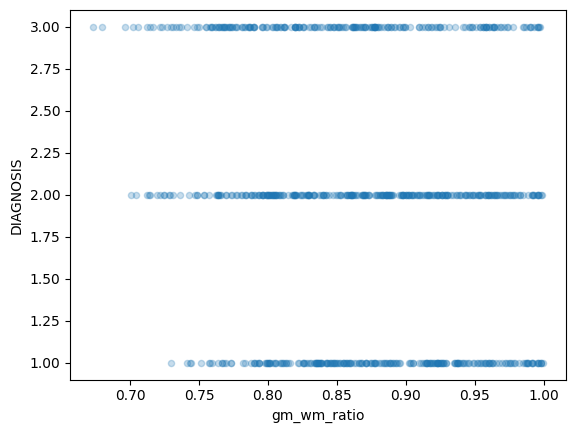

In [ ]:
df.plot.scatter(x='gm_wm_ratio', y='DIAGNOSIS', alpha=0.25)
plt.show()

In [ ]:
df['EXAMDATE'] = df['EXAMDATE'].astype('datetime64[ns]')

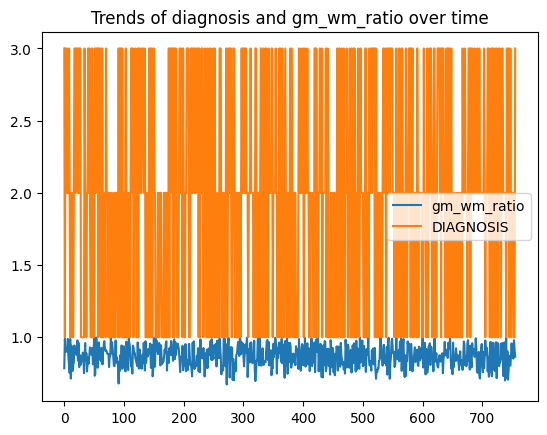

In [ ]:
df.plot.line(y=['gm_wm_ratio', 'DIAGNOSIS'], title='Trends of diagnosis and gm_wm_ratio over time')
plt.show()

In [ ]:
df["gm_wm_ratio"]

0      0.785305
1      0.988811
2      0.911814
3      0.900393
4      0.924892
         ...   
751    0.885454
752    0.852083
753    0.978896
754    0.915312
755    0.865476
Name: gm_wm_ratio, Length: 756, dtype: float64

In [ ]:
df["DIAGNOSIS"].value_counts()

DIAGNOSIS
2.0    296
1.0    242
3.0    218
Name: count, dtype: int64

In [ ]:
from scipy.stats import shapiro

for group in [1, 2, 3]:
    stat, p = shapiro(df[df["DIAGNOSIS"] == group]["gm_wm_ratio"])
    print(group, "Shapiro-Wilk p =", p)


1 Shapiro-Wilk p = 0.0002608990007308487
2 Shapiro-Wilk p = 5.103954321365262e-05
3 Shapiro-Wilk p = 0.000880783863673559


In [25]:
from scipy.stats import levene

cn = df[df["DIAGNOSIS"] == 1]["gm_wm_ratio"]
mci= df[df["DIAGNOSIS"] == 2]["gm_wm_ratio"]
ad= df[df["DIAGNOSIS"] == 3]["gm_wm_ratio"]

stat, p = levene(cn, mci, ad)
print("Levene’s test p =", p)


Levene’s test p = 0.05028548606080465


In [41]:
import statsmodels.api as sm

# Add intercept
X = sm.add_constant(df['gm_wm_ratio'])
y = df['DIAGNOSIS']

# Fit multinomial logistic regression
model = sm.MNLogit(y, X)
result = model.fit()
print(result.summary())


Optimization terminated successfully.
         Current function value: 1.077776
         Iterations 5
                          MNLogit Regression Results                          
Dep. Variable:              DIAGNOSIS   No. Observations:                  756
Model:                        MNLogit   Df Residuals:                      752
Method:                           MLE   Df Model:                            2
Date:                Sat, 27 Sep 2025   Pseudo R-squ.:                 0.01154
Time:                        19:03:48   Log-Likelihood:                -814.80
converged:                       True   LL-Null:                       -824.31
Covariance Type:            nonrobust   LLR p-value:                 7.402e-05
DIAGNOSIS=2       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.0221      1.052      1.923      0.055      -0.039       4.083
gm_wm_ratio    -2.0770    

In [44]:
import numpy as np
odds_ratios = np.exp(result.params)
print(odds_ratios)


                    0           1
const        7.554005  109.109688
gm_wm_ratio  0.125311    0.003963


# gmwm_ratio_diagnosis_UNIQUES 

In [7]:
df_uniq = df_uniq.sort_values(by='EXAMDATE', ascending=False)

In [9]:
len(df_uniq)

456

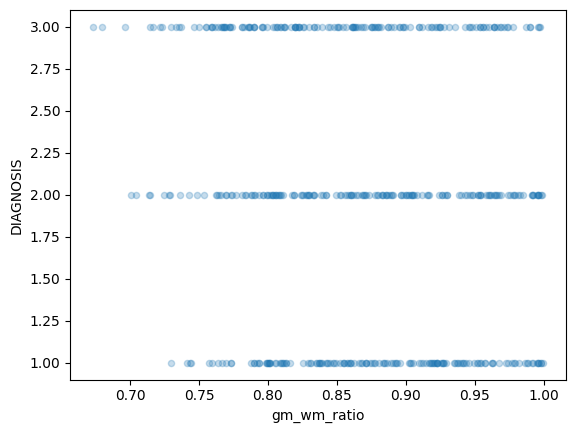

In [10]:
df_uniq.plot.scatter(x='gm_wm_ratio', y='DIAGNOSIS', alpha=0.25)
plt.show()

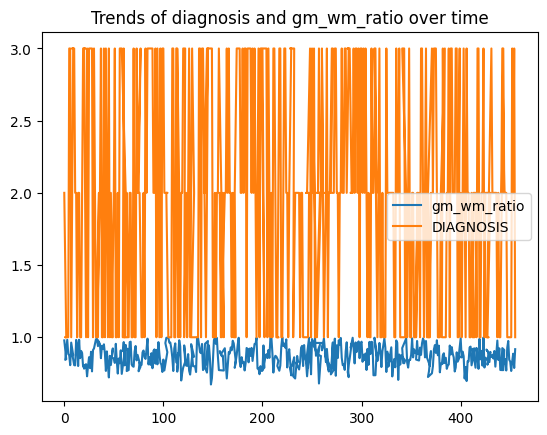

In [11]:
df_uniq.plot.line(y=['gm_wm_ratio', 'DIAGNOSIS'], title='Trends of diagnosis and gm_wm_ratio over time')
plt.show()

In [12]:
df_uniq["gm_wm_ratio"]

0      0.978069
2      0.848107
1      0.843078
3      0.982280
4      0.884358
         ...   
451    0.766319
452    0.833773
453    0.885894
454    0.786971
455    0.917259
Name: gm_wm_ratio, Length: 456, dtype: float64

In [13]:
df_uniq["DIAGNOSIS"].value_counts()

DIAGNOSIS
2.0    159
3.0    149
1.0    148
Name: count, dtype: int64

## shapiro wilk, levene - to prove not normal distribution but equal variances

In [14]:
from scipy.stats import shapiro

for group in [1, 2, 3]:
    stat, p = shapiro(df_uniq[df_uniq["DIAGNOSIS"] == group]["gm_wm_ratio"])
    print(group, "Shapiro-Wilk p =", p)


1 Shapiro-Wilk p = 0.004387577845986915
2 Shapiro-Wilk p = 0.001003582748036701
3 Shapiro-Wilk p = 0.011200969057355785


In [15]:
from scipy.stats import levene

cn_uniq = df_uniq[df_uniq["DIAGNOSIS"] == 1]["gm_wm_ratio"]
mci_uniq = df_uniq[df_uniq["DIAGNOSIS"] == 2]["gm_wm_ratio"]
ad_uniq = df_uniq[df_uniq["DIAGNOSIS"] == 3]["gm_wm_ratio"]

stat, p = levene(cn_uniq, mci_uniq, ad_uniq)
print("Levene’s test p =", p)


Levene’s test p = 0.19877105551985352


## kruskal wallis, mann whitney

In [19]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(cn_uniq, ad_uniq, alternative='two-sided')
print("Mann-Whitney U statistic (CN/AD):", stat, "p-value:", p)

stat, p = mannwhitneyu(cn_uniq, mci_uniq, alternative='two-sided')
print("Mann-Whitney U statistic (CN/MCI):", stat, "p-value:", p)

stat, p = mannwhitneyu(mci_uniq, ad_uniq, alternative='two-sided')
print("Mann-Whitney U statistic (MCI/AD):", stat, "p-value:", p)


Mann-Whitney U statistic (CN/AD): 13423.0 p-value: 0.001201850547013349
Mann-Whitney U statistic (CN/MCI): 12551.0 p-value: 0.3127655765065579
Mann-Whitney U statistic (MCI/AD): 13581.0 p-value: 0.026326512250435134


In [42]:
import numpy as np
from scipy.stats import mannwhitneyu

def rank_biserial(u_stat, n1, n2):
    return 1 - (2 * u_stat) / (n1 * n2)

# Example CN vs AD
u_stat, p_val = mannwhitneyu(cn_uniq, ad_uniq, alternative="two-sided")
r = rank_biserial(u_stat, len(cn_uniq), len(ad_uniq))
print("U =", u_stat, "p =", p_val, "r =", r)


U = 13423.0 p = 0.001201850547013349 r = -0.2173952475965899


In [49]:
from scipy.stats import kruskal
# Example
H, p = kruskal(cn_uniq, mci_uniq, ad_uniq)
n = len(cn_uniq) + len(mci_uniq) + len(ad_uniq)
k = 3
eta_sq = (H - k + 1) / (n - k)

print("Kruskal–Wallis H-statistic: H =", H, "p =", p, "η² =", eta_sq)


Kruskal–Wallis H-statistic: H = 10.86660995741886 p = 0.004368633676033883 η² = 0.019573090413728168


In [47]:
import pandas as pd
import scikit_posthocs as sp
from statsmodels.stats.multitest import multipletests

# Example: Kruskal–Wallis already showed significance
# Now do post-hoc Dunn's test
# df has columns: gm_wm_ratio, DIAGNOSIS (with 3+ groups)

# Raw Dunn’s test p-values (pairwise)
dunn = sp.posthoc_dunn(df, val_col="gm_wm_ratio", group_col="DIAGNOSIS", p_adjust=None)

# Flatten results into long format
pairs = []
raw_p = []

groups = dunn.columns
for i in range(len(groups)):
    for j in range(i+1, len(groups)):
        pairs.append(f"{groups[i]} vs {groups[j]}")
        raw_p.append(dunn.iloc[i, j])

# Multiple comparisons correction
_, p_bonf, _, _ = multipletests(raw_p, method="bonferroni")
_, p_fdr, _, _ = multipletests(raw_p, method="fdr_bh")

results = pd.DataFrame({
    "Comparison": pairs,
    "Raw_p": raw_p,
    "Bonferroni_p": p_bonf,
    "FDR_p": p_fdr
})

print(results)


   Comparison     Raw_p  Bonferroni_p     FDR_p
0  1.0 vs 2.0  0.127166      0.381497  0.127166
1  1.0 vs 3.0  0.000053      0.000158  0.000158
2  2.0 vs 3.0  0.005977      0.017930  0.008965


In [54]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests

# ----------------------------
# Kruskal-Wallis test (3 groups)
# ----------------------------
H, p_kw = kruskal(cn_uniq, mci_uniq, ad_uniq)
n = len(cn_uniq) + len(mci_uniq) + len(ad_uniq)
k = 3
eta_sq = (H - k + 1) / (n - k)  # effect size

print(f"Kruskal-Wallis: H={H:.3f}, p={p_kw:.5f}, η²={eta_sq:.3f}")

# ----------------------------
# Pairwise Mann-Whitney U tests
# ----------------------------
def rank_biserial(u_stat, n1, n2):
    return 1 - (2 * u_stat) / (n1 * n2)

results = []

# CN vs AD
u1, p1 = mannwhitneyu(cn_uniq, ad_uniq, alternative="two-sided")
r1 = rank_biserial(u1, len(cn_uniq), len(ad_uniq))
results.append(("CN vs AD", u1, p1, r1))

# CN vs MCI
u2, p2 = mannwhitneyu(cn_uniq, mci_uniq, alternative="two-sided")
r2 = rank_biserial(u2, len(cn_uniq), len(mci_uniq))
results.append(("CN vs MCI", u2, p2, r2))

# MCI vs AD
u3, p3 = mannwhitneyu(mci_uniq, ad_uniq, alternative="two-sided")
r3 = rank_biserial(u3, len(mci_uniq), len(ad_uniq))
results.append(("MCI vs AD", u3, p3, r3))

# ----------------------------
# Multiple comparison correction
# ----------------------------
raw_pvals = [p1, p2, p3]

# Bonferroni
_, pvals_bonf, _, _ = multipletests(raw_pvals, method='bonferroni')

# Benjamini-Hochberg (FDR)
_, pvals_bh, _, _ = multipletests(raw_pvals, method='fdr_bh')

# ----------------------------
# Build results table
# ----------------------------
df_results = pd.DataFrame(results, columns=["Comparison", "U", "Raw_p", "Rank_biserial_r"])
df_results["Bonferroni_p"] = pvals_bonf
df_results["BH_p"] = pvals_bh
df_results["Significant_Bonf"] = df_results["Bonferroni_p"] < 0.05
df_results["Significant_BH"] = df_results["BH_p"] < 0.05

print(df_results)


Kruskal-Wallis: H=10.867, p=0.00437, η²=0.020
  Comparison        U     Raw_p  Rank_biserial_r  Bonferroni_p      BH_p  \
0   CN vs AD  13423.0  0.001202        -0.217395      0.003606  0.003606   
1  CN vs MCI  12551.0  0.312766        -0.066718      0.938297  0.312766   
2  MCI vs AD  13581.0  0.026327        -0.146511      0.078980  0.039490   

   Significant_Bonf  Significant_BH  
0              True            True  
1             False           False  
2             False            True  


# final